<a href="https://colab.research.google.com/github/abdulsamad00529/ML-assignments-FlyRank-AI/blob/main/w04_baseline_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import pandas as pd
import requests
import os

# Create the directory if it doesn't exist
os.makedirs('data/raw', exist_ok=True)

# URL for the raw CSV file on GitHub
csv_url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"

# Path where the file should be saved
file_path = 'data/raw/content_refresh_anonymized.csv'

# Download the file
response = requests.get(csv_url)
response.raise_for_status() # Raise an exception for bad status codes

with open(file_path, 'wb') as f:
    f.write(response.content)

print(f"Downloaded {file_path}")

df = pd.read_csv(file_path)
display(df.columns)

Downloaded data/raw/content_refresh_anonymized.csv


Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

### Data Types and Missing Values Check

In [ ]:
print('DataFrame Info (Data Types and Non-Null Counts):')
df.info()

DataFrame Info (Data Types and Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  in

In [ ]:
print('\nMissing values in `ctr` column:')
print(df['ctr'].isnull().sum())

print('\nMissing values in `avg_position` column:')
print(df['avg_position'].isnull().sum())


Missing values in `ctr` column:
0

Missing values in `avg_position` column:
0


## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

### Generate 'score' and 'reason_code' columns

In [ ]:
import numpy as np

# Define the boolean conditions based on the refined rule
is_stale = (df['days_since_last_update'] >= 180)
is_poor_seo = (df['avg_position'] > 20)
is_low_engagement = (df['ctr'] < 0.005)

# Calculate the 'score' column
# The score is non-zero only if ALL three conditions are met, scaled by impressions_90d
df['score'] = (is_stale & is_poor_seo & is_low_engagement).astype(int) * df['impressions_90d']

print("Generated 'score' column. Displaying first 5 rows with score:")
display(df[['content_id', 'days_since_last_update', 'avg_position', 'ctr', 'impressions_90d', 'score']].head())

Generated 'score' column. Displaying first 5 rows with score:


,content_id,days_since_last_update,avg_position,ctr,impressions_90d,score
0,content_304f48230142,20,10.6,0.76,3803,0
1,content_a1fb4e703a9e,25,20.3,0.05,15320,0
2,content_9aa793d4d895,20,36.5,0.09,12581,0
3,content_331d6c4de07b,22,6.2,0.49,11751,0
4,content_d99b7a2d90ca,14,44.0,0.13,19140,0


In [ ]:
# Assign granular reason codes
conditions = [
    is_stale & is_poor_seo & is_low_engagement,
    is_stale & is_poor_seo & ~is_low_engagement,
    is_stale & ~is_poor_seo & is_low_engagement,
    ~is_stale & is_poor_seo & is_low_engagement,
    is_stale & ~is_poor_seo & ~is_low_engagement,
    ~is_stale & is_poor_seo & ~is_low_engagement,
    ~is_stale & ~is_poor_seo & is_low_engagement
]
choices = [
    'all_three_criteria',
    'stale_poor_seo',
    'stale_low_engagement',
    'poor_seo_low_engagement',
    'stale_content',
    'poor_seo',
    'low_engagement'
]

df['reason_code'] = np.select(conditions, choices, default='no_action')

print("Generated 'reason_code' column. Displaying first 5 rows with score and reason code:")
display(df[['content_id', 'days_since_last_update', 'avg_position', 'ctr', 'score', 'reason_code']].head())

Generated 'reason_code' column. Displaying first 5 rows with score and reason code:


,content_id,days_since_last_update,avg_position,ctr,score,reason_code
0,content_304f48230142,20,10.6,0.76,0,no_action
1,content_a1fb4e703a9e,25,20.3,0.05,0,poor_seo
2,content_9aa793d4d895,20,36.5,0.09,0,poor_seo
3,content_331d6c4de07b,22,6.2,0.49,0,no_action
4,content_d99b7a2d90ca,14,44.0,0.13,0,poor_seo


## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

### Build the ranked queue (writes the CSV)

In [ ]:
import os

# Sort the DataFrame by 'score' in descending order
ranked_queue = df.sort_values(by='score', ascending=False)

# Create the output directory if it doesn't exist
output_dir = 'work/outputs/'
os.makedirs(output_dir, exist_ok=True)

# Define the output file path
output_file_path = os.path.join(output_dir, 'baseline_action_score.csv')

# Save the ranked queue to a CSV file
ranked_queue.to_csv(output_file_path, index=False)

print(f"Ranked queue saved to {output_file_path}")
print("Displaying the top 5 entries of the ranked queue:")
display(ranked_queue[['content_id', 'score', 'reason_code', 'days_since_last_update', 'avg_position', 'ctr', 'impressions_90d']].head())

Ranked queue saved to work/outputs/baseline_action_score.csv
Displaying the top 5 entries of the ranked queue:


,content_id,score,reason_code,days_since_last_update,avg_position,ctr,impressions_90d
698,content_b16bd7307b39,4590,all_three_criteria,194,31.0,0.0,4590
3507,content_074ba6ead17b,533,all_three_criteria,183,48.0,0.0,533
15790,content_6476d1d8c050,304,all_three_criteria,313,67.8,0.0,304
9346,content_d25a099b3726,202,all_three_criteria,305,64.5,0.0,202
7509,content_7a888d3d99c8,95,all_three_criteria,313,67.6,0.0,95


### Calculate Precision@K

In [ ]:
def precision_at_k(scores, labels, k):
    import numpy as np
    order = np.argsort(-np.asarray(scores)) # Sort in descending order of scores
    top_k_labels = np.asarray(labels)[order[:k]]
    return top_k_labels.mean()

# For this baseline, our 'labels' are implicitly defined by the conditions for scoring.
# If score > 0, it means the item met our criteria for review.
# Therefore, we can create a 'label' based on the score itself for now.
# In a real scenario, 'labels' would be external, e.g., expert-reviewed relevance.

# Create a proxy 'label': 1 if score > 0, 0 otherwise.
# This serves to evaluate how many of the top K items actually meet our 'review' criteria.
# Note: This is an internal consistency check, not a true external validation yet.
ranked_queue['is_relevant'] = (ranked_queue['score'] > 0).astype(int)

K_value = 20 # As per the skill document, we review the top 20

# Calculate precision@K
p_at_k = precision_at_k(ranked_queue['score'], ranked_queue['is_relevant'], K_value)

print(f"Precision@{K_value}: {p_at_k:.4f}")
print(f"Base rate (proportion of items with score > 0 in the whole dataset): {ranked_queue['is_relevant'].mean():.4f}")

Precision@20: 1.0000
Base rate (proportion of items with score > 0 in the whole dataset): 0.0007


## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

### Top-20 Review (Displaying for manual inspection)

In [ ]:
# Display the top 20 entries for manual review
display(ranked_queue[['content_id', 'score', 'reason_code', 'days_since_last_update', 'avg_position', 'ctr', 'impressions_90d']].head(20))

,content_id,score,reason_code,days_since_last_update,avg_position,ctr,impressions_90d
698,content_b16bd7307b39,4590,all_three_criteria,194,31.0,0.0,4590
3507,content_074ba6ead17b,533,all_three_criteria,183,48.0,0.0,533
15790,content_6476d1d8c050,304,all_three_criteria,313,67.8,0.0,304
9346,content_d25a099b3726,202,all_three_criteria,305,64.5,0.0,202
7509,content_7a888d3d99c8,95,all_three_criteria,313,67.6,0.0,95
11494,content_d34c89fad803,80,all_three_criteria,183,20.1,0.0,80
22248,content_607ea6e3f876,64,all_three_criteria,301,20.4,0.0,64
18652,content_0173fb0dc986,48,all_three_criteria,183,23.0,0.0,48
21313,content_d5fe8e70ce86,41,all_three_criteria,183,21.5,0.0,41
505,content_bfa3d6688324,27,all_three_criteria,183,21.1,0.0,27


## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

### Identifying 'Weak Picks' (impressions_90d < 50)

In [ ]:
weak_picks = ranked_queue[ranked_queue['impressions_90d'] < 50]
print(f"Number of 'weak picks' identified (impressions_90d < 50): {len(weak_picks)}")
display(weak_picks[['content_id', 'score', 'reason_code', 'days_since_last_update', 'avg_position', 'ctr', 'impressions_90d']])

Number of 'weak picks' identified (impressions_90d < 50): 6479


,content_id,score,reason_code,days_since_last_update,avg_position,ctr,impressions_90d
18652,content_0173fb0dc986,48,all_three_criteria,183,23.0,0.0,48
21313,content_d5fe8e70ce86,41,all_three_criteria,183,21.5,0.0,41
505,content_bfa3d6688324,27,all_three_criteria,183,21.1,0.0,27
8860,content_adfc46f3f033,22,all_three_criteria,183,23.7,0.0,22
21201,content_afd26a07382d,15,all_three_criteria,305,45.1,0.0,15
...,...,...,...,...,...,...,...
9993,content_9748c5853fe6,0,poor_seo_low_engagement,22,43.3,0.0,47
10006,content_a35029d5d818,0,low_engagement,8,5.9,0.0,29
10004,content_d2a29c611227,0,low_engagement,20,5.0,0.0,1
10003,content_c7120ae9bd18,0,low_engagement,20,0.0,0.0,1


### Correlation between 'impressions_90d' and 'score' for 'Weak Picks'

In [ ]:
correlation_weak_picks = weak_picks['impressions_90d'].corr(weak_picks['score'])
print(f"Correlation between 'impressions_90d' and 'score' for weak picks: {correlation_weak_picks:.4f}")

Correlation between 'impressions_90d' and 'score' for weak picks: 0.0407


### Distribution of 'impressions_90d' for the Entire Ranked Queue

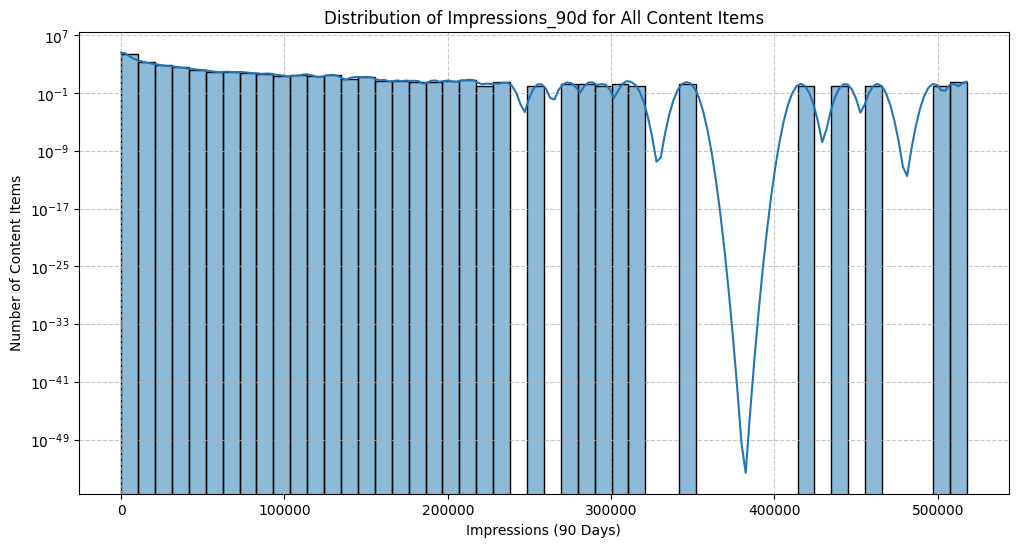

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(ranked_queue['impressions_90d'], bins=50, kde=True)
plt.title('Distribution of Impressions_90d for All Content Items')
plt.xlabel('Impressions (90 Days)')
plt.ylabel('Number of Content Items')
plt.yscale('log') # Use a log scale for y-axis if there's a wide range of values
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Correlation between 'score' and 'impressions_90d' for the full Ranked Queue

In [ ]:
correlation_full_queue = ranked_queue['score'].corr(ranked_queue['impressions_90d'])
print(f"Correlation between 'score' and 'impressions_90d' for the full ranked queue: {correlation_full_queue:.4f}")

Correlation between 'score' and 'impressions_90d' for the full ranked queue: -0.0007


### Scatter Plot: 'score' vs. 'impressions_90d' for the full Ranked Queue

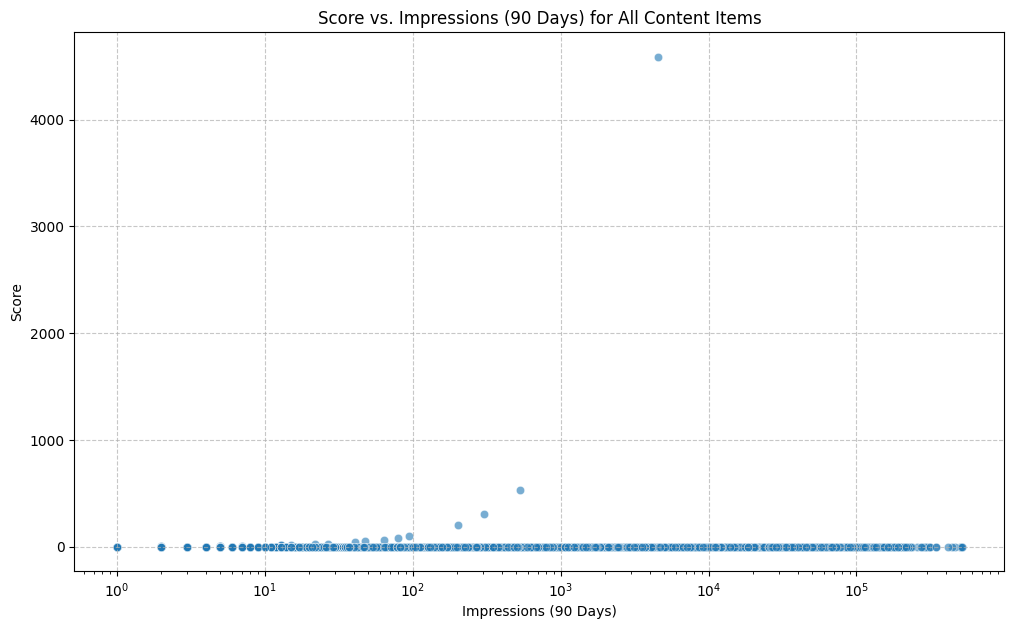

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(x='impressions_90d', y='score', data=ranked_queue, alpha=0.6)
plt.title('Score vs. Impressions (90 Days) for All Content Items')
plt.xlabel('Impressions (90 Days)')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xscale('log') # Use a log scale for x-axis if impressions span a very wide range
plt.show()

In [ ]:
not_weak_picks = ranked_queue[ranked_queue['impressions_90d'] >= 50]

average_score_weak_picks = weak_picks['score'].mean()
average_score_not_weak_picks = not_weak_picks['score'].mean()

print(f"Average score for 'weak picks' (impressions_90d < 50): {average_score_weak_picks:.4f}")
print(f"Average score for 'not weak picks' (impressions_90d >= 50): {average_score_not_weak_picks:.4f}")

Average score for 'weak picks' (impressions_90d < 50): 0.0309
Average score for 'not weak picks' (impressions_90d >= 50): 0.2495


In [ ]:
# Calculate the median search_volume from the original DataFrame to define 'high' search volume
median_search_volume = df['search_volume'].median()
print(f"Median search volume: {median_search_volume}")

# Filter weak_picks for those with search_volume greater than or equal to the median
high_impact_weak_picks = weak_picks[weak_picks['search_volume'] >= median_search_volume]

print(f"\nNumber of 'high-impact weak picks' (impressions_90d < 50 AND search_volume >= {median_search_volume}): {len(high_impact_weak_picks)}")

# Display relevant columns for these high-impact weak picks
display(high_impact_weak_picks[['content_id', 'score', 'reason_code', 'impressions_90d', 'search_volume']].head())

Median search volume: 10.0

Number of 'high-impact weak picks' (impressions_90d < 50 AND search_volume >= 10.0): 2815


,content_id,score,reason_code,impressions_90d,search_volume
21201,content_afd26a07382d,15,all_three_criteria,15,10.0
26249,content_dd413158df3c,13,all_three_criteria,13,20.0
7045,content_026a1e2a82fd,13,all_three_criteria,13,10.0
15882,content_129753e3095f,7,all_three_criteria,7,10.0
22860,content_ab18b5811c02,5,all_three_criteria,5,10.0


In [ ]:
display(high_impact_weak_picks.describe())

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,score,is_relevant
count,2815.000000,2815.000000,2815.000000,2323.000000,2323.000000,2815.000000,2815.000000,2815.000000,2815.000000,2815.000000,...,2815.000000,2815.000000,2815.000000,2815.000000,2815.000000,2810.000000,2815.000000,1485.000000,2815.000000,2815.000000
mean,229.737123,0.266135,0.960071,2575.453724,16900.578993,13.331794,0.039787,3.338544,3.159858,3.077087,...,4.795027,35.478508,0.283481,17.062060,1.655211,23.170014,1.018171,-16.904983,0.018828,0.001776
std,1373.731373,0.351337,3.819644,1175.067609,8665.038525,13.649149,0.246903,6.759299,6.207787,5.908214,...,0.723435,38.658954,2.085747,21.174817,8.950981,35.561063,9.502583,175.747872,0.475409,0.042115
min,10.000000,0.000000,0.000000,841.000000,5567.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.000000
25%,10.000000,0.000000,0.000000,1490.000000,9664.500000,2.000000,0.000000,1.000000,1.000000,1.000000,...,4.000000,20.000000,0.000000,4.800000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.000000
50%,20.000000,0.070000,0.000000,2627.000000,16818.000000,7.000000,0.000000,2.000000,2.000000,2.000000,...,5.000000,20.000000,0.000000,9.000000,0.000000,0.000000,0.000000,-67.600000,0.000000,0.000000
75%,50.000000,0.430000,0.555000,3402.500000,21732.000000,22.000000,0.000000,3.000000,3.000000,3.000000,...,5.000000,22.000000,0.000000,21.200000,0.000000,40.000000,0.000000,0.000000,0.000000,0.000000
max,33100.000000,1.000000,100.360000,7423.000000,111074.000000,49.000000,7.000000,181.000000,177.000000,170.000000,...,6.000000,313.000000,33.330000,245.000000,100.000000,200.000000,200.000000,2400.000000,15.000000,1.000000


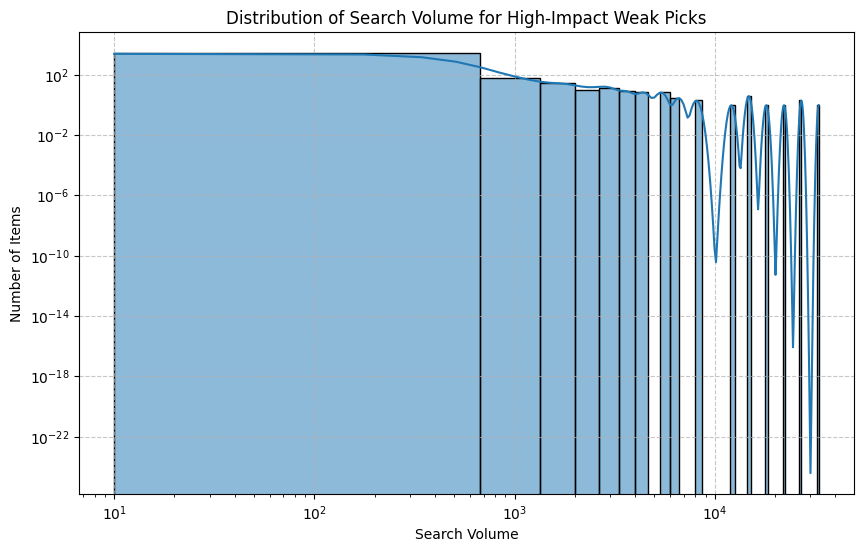

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(high_impact_weak_picks['search_volume'], bins=50, kde=True)
plt.title('Distribution of Search Volume for High-Impact Weak Picks')
plt.xlabel('Search Volume')
plt.ylabel('Number of Items')
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log') # Use log scale for y-axis if distribution is heavily skewed
plt.xscale('log') # Use log scale for x-axis if search volume has a wide range
plt.show()

In [ ]:
print("Distribution of 'competition_level' in high_impact_weak_picks:")
display(high_impact_weak_picks['competition_level'].value_counts(dropna=False))

Distribution of 'competition_level' in high_impact_weak_picks:


,count
competition_level,
LOW,1988
HIGH,518
MEDIUM,309


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.